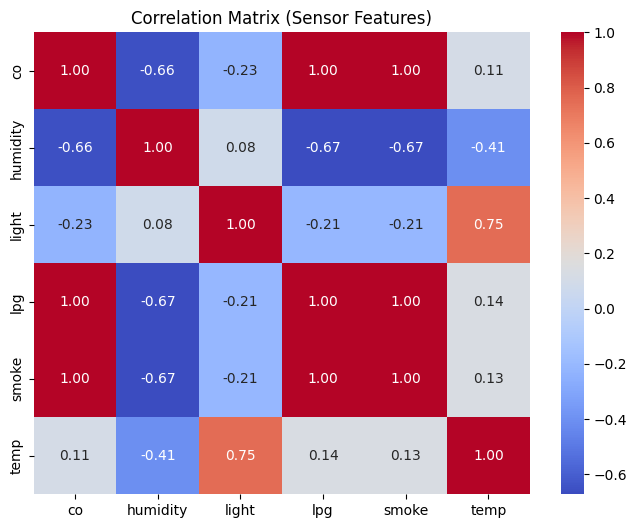


Strong Feature Correlations:
co ↔ humidity : -0.66
co ↔ lpg : 1.00
co ↔ smoke : 1.00
humidity ↔ lpg : -0.67
humidity ↔ smoke : -0.67
light ↔ temp : 0.75
lpg ↔ smoke : 1.00
Execution Time: 2.9892711639404297


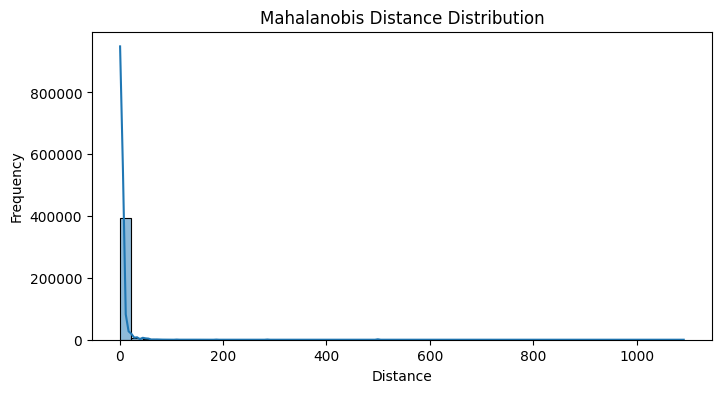

Threshold: 16.811893829770927
   Mahalanobis_Distance  Outlier
0              1.790144    False
1              4.512264    False
2              1.712025    False
3             13.735195    False
4              1.732714    False


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler
import time

# Load dataset
df = pd.read_csv("iot_telemetry_data.csv")

# ---------------------------
# 1. Select only numeric columns
# ---------------------------
features = ['co', 'humidity', 'light', 'lpg', 'smoke', 'temp']

X = df[features].copy()



# ---------------------------
# 2. Normalize data
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame for analysis
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# ===============================
# 1. CORRELATION MATRIX
# ===============================
corr_matrix = X_scaled_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Sensor Features)")
plt.show()

# ===============================
# 2. STRONG CORRELATION CHECK
# ===============================
threshold = 0.5
print("\nStrong Feature Correlations:")

for i in range(len(features)):
    for j in range(i+1, len(features)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > threshold:
            print(f"{features[i]} ↔ {features[j]} : {val:.2f}")
# ---------------------------
# 3. Mahalanobis Distance
# ---------------------------
start = time.time()

mean = np.mean(X_scaled, axis=0)
cov = np.cov(X_scaled, rowvar=False)

# Use pseudo-inverse (safe)
cov_inv = np.linalg.pinv(cov)

diff = X_scaled - mean

md = []
for i in range(len(diff)):
    d = diff[i]
    dist = np.dot(np.dot(d, cov_inv), d.T)
    md.append(dist)
end = time.time()
print("Execution Time:", end - start)
md = np.array(md)

# ---------------------------
# 4. Threshold using Chi-square
# ---------------------------
df_dim = X.shape[1]
threshold = chi2.ppf(0.99, df_dim)  # 99% confidence

# ---------------------------
# 5. Detect Outliers
# ---------------------------
df['Mahalanobis_Distance'] = md
df['Outlier'] = md > threshold

# ---------------------------
# 6. Results
# ---------------------------
print("Threshold:", threshold)
print(df[['Mahalanobis_Distance', 'Outlier']].head())

# Save output
df.to_csv("output_with_mahalanobis.csv", index=False)

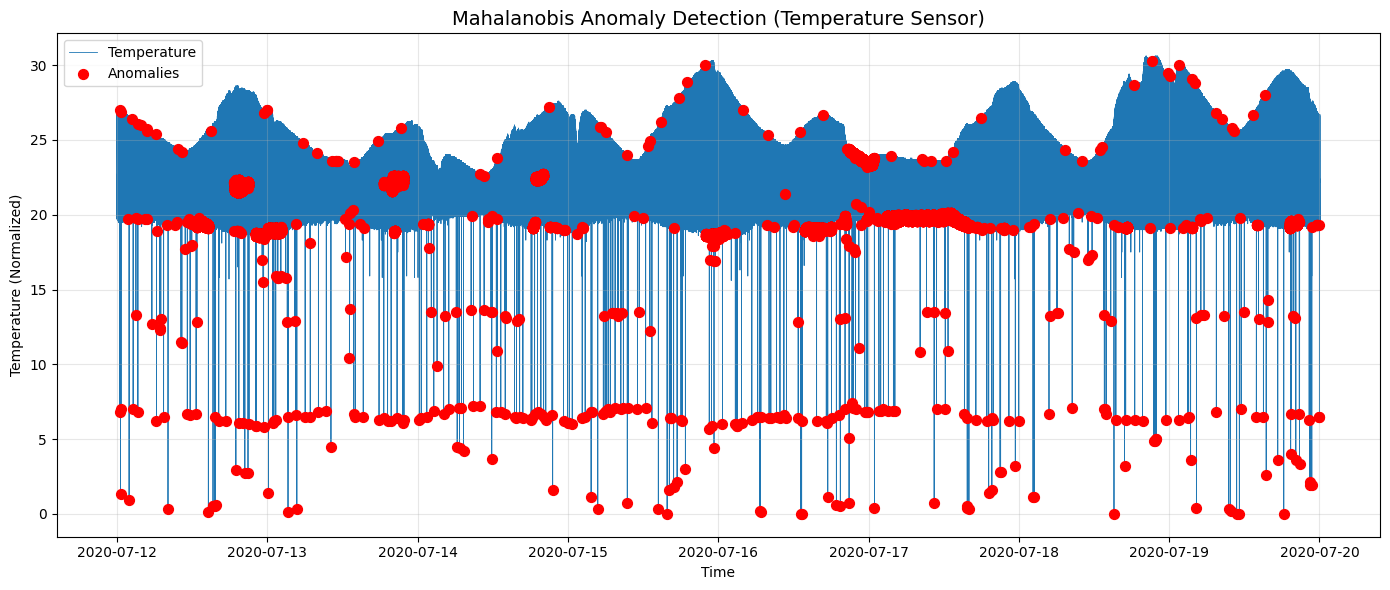

In [3]:
import matplotlib.pyplot as plt

data = df.copy()

# Convert timestamp
if "ts" in data.columns:
    data["ts"] = pd.to_numeric(data["ts"], errors="coerce")
    data["ts"] = pd.to_datetime(data["ts"], unit="s")

# Separate anomalies
anomalies = data[data["Outlier"] == True]

plt.figure(figsize=(14, 6))

# Plot normal data (blue line)
plt.plot(
    data["ts"],
    data["temp"],
    linewidth=0.6,
    label="Temperature",
    zorder=1
)

plt.scatter(
    anomalies["ts"],
    anomalies["temp"],
    color="red",          # IMPORTANT
    s=50,                 # Bigger size
    label="Anomalies",
    zorder=3              # On top of line
)

plt.title("Mahalanobis Anomaly Detection (Temperature Sensor)", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Temperature (Normalized)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

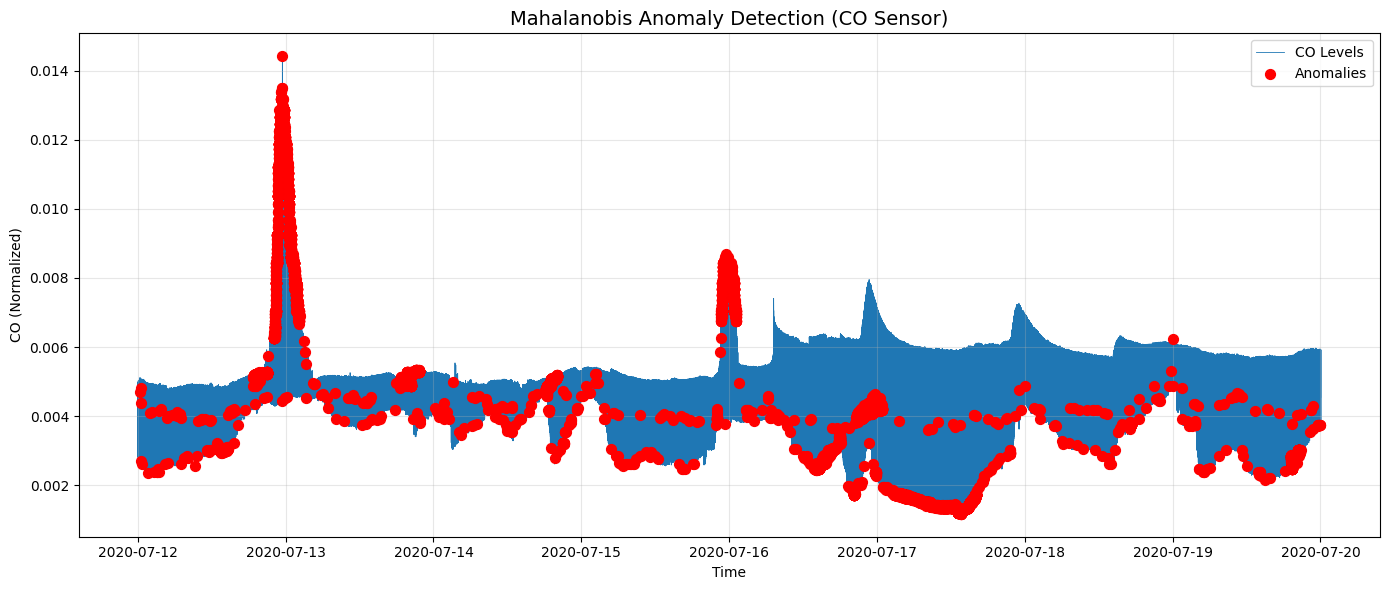

In [4]:
import matplotlib.pyplot as plt

data = df.copy()

# Convert timestamp
if "ts" in data.columns:
    data["ts"] = pd.to_numeric(data["ts"], errors="coerce")
    data["ts"] = pd.to_datetime(data["ts"], unit="s")

# Separate anomalies
anomalies = data[data["Outlier"] == True]

plt.figure(figsize=(14, 6))

# Plot normal data (blue line)
plt.plot(
    data["ts"],
    data["co"],
    linewidth=0.6,
    label="CO Levels",
    zorder=1
)

plt.scatter(
    anomalies["ts"],
    anomalies["co"],
    color="red",          
    s=50,                 
    label="Anomalies",
    zorder=3               
)

plt.title("Mahalanobis Anomaly Detection (CO Sensor)", fontsize=14)
plt.xlabel("Time")
plt.ylabel("CO (Normalized)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

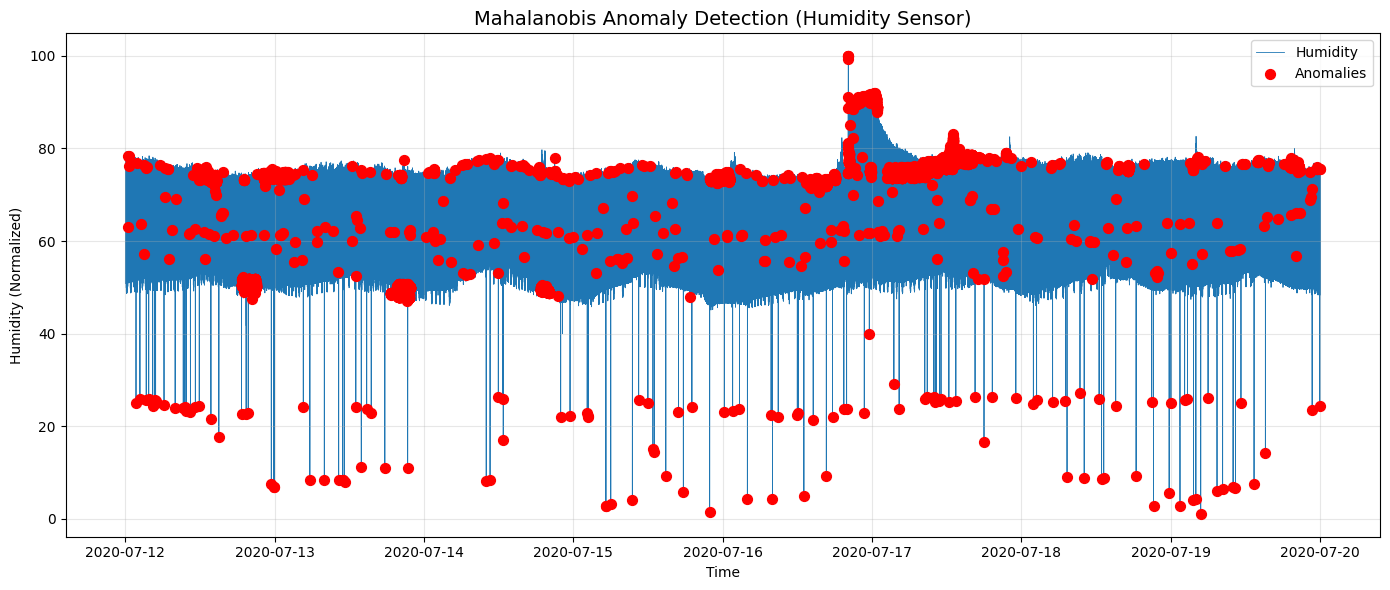

In [5]:
import matplotlib.pyplot as plt

data = df.copy()

# Convert timestamp
if "ts" in data.columns:
    data["ts"] = pd.to_numeric(data["ts"], errors="coerce")
    data["ts"] = pd.to_datetime(data["ts"], unit="s")

# Separate anomalies
anomalies = data[data["Outlier"] == True]

plt.figure(figsize=(14, 6))

# Plot normal data (blue line)
plt.plot(
    data["ts"],
    data["humidity"],
    linewidth=0.6,
    label="Humidity",
    zorder=1
)

plt.scatter(
    anomalies["ts"],
    anomalies["humidity"],
    color="red",          # IMPORTANT
    s=50,                 # Bigger size
    label="Anomalies",
    zorder=3              # On top of line
)

plt.title("Mahalanobis Anomaly Detection (Humidity Sensor)", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Humidity (Normalized)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# STAGE 2: SUPERVISED LEARNING (Random Forest)
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------
# 1. LOAD LABELED DATASET (Mahalanobis output)
# ------------------------------------------
data = pd.read_csv("output_with_mahalanobis.csv")

print("Dataset Shape:", data.shape)

# ------------------------------------------
# 2. DEFINE FEATURES & TARGET
# ------------------------------------------
# Convert boolean Outlier → int (VERY IMPORTANT)
data["Outlier"] = data["Outlier"].astype(int)

# Drop unnecessary columns
X = data.drop(columns=["Outlier", "device", "ts", "Mahalanobis_Distance"])
y = data["Outlier"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# ------------------------------------------
# 3. TRAIN-TEST SPLIT
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y   # keeps anomaly ratio same
)

# ------------------------------------------
# 4. TRAIN RANDOM FOREST MODEL
# ------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"   # IMPORTANT (handles imbalance)
)

rf_model.fit(X_train, y_train)

print("Model Training Completed")

# ------------------------------------------
# 5. EVALUATE MODEL
# ------------------------------------------
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n--- Model Performance ---")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ------------------------------------------
# 6. Prediction Probabilities (for UI)
# ------------------------------------------
probs = rf_model.predict_proba(X_test[:10])

print("\nSample Probabilities:")
print(probs)

Dataset Shape: (405184, 11)
Features Shape: (405184, 7)
Target Shape: (405184,)
Model Training Completed

--- Model Performance ---
Accuracy : 0.9999
Precision: 0.9989
Recall   : 0.9979
F1 Score : 0.9984

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    115852
           1       1.00      1.00      1.00      5704

    accuracy                           1.00    121556
   macro avg       1.00      1.00      1.00    121556
weighted avg       1.00      1.00      1.00    121556


Sample Probabilities:
[[1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [7]:
# ==========================================
# STAGE 3: SUPERVISED LEARNING (MLP - Neural Network)
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------
# 1. LOAD DATA
# ------------------------------------------
data = pd.read_csv("output_with_mahalanobis.csv")

# Convert boolean → int
data["Outlier"] = data["Outlier"].astype(int)

# ------------------------------------------
# 2. FEATURES & TARGET
# ------------------------------------------
X = data.drop(columns=["Outlier", "device", "ts", "Mahalanobis_Distance"])
y = data["Outlier"]

# ------------------------------------------
# 3. TRAIN-TEST SPLIT
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# 4. NORMALIZATION (VERY IMPORTANT for MLP)
# ------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------
# 5. MODEL
# ------------------------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# ------------------------------------------
# 6. TRAIN
# ------------------------------------------
mlp.fit(X_train, y_train)

print("MLP Training Completed")

# ------------------------------------------
# 7. PREDICTION (with tuned threshold)
# ------------------------------------------
y_prob = mlp.predict_proba(X_test)[:, 1]

# Slightly lower threshold → better anomaly detection
y_pred = (y_prob > 0.45).astype(int)

# ------------------------------------------
# 8. EVALUATION
# ------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n--- Neural Network Performance ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

MLP Training Completed

--- Neural Network Performance ---
Accuracy : 0.9985
Precision: 0.9704
Recall   : 0.9995
F1 Score : 0.9847

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    115852
           1       0.97      1.00      0.98      5704

    accuracy                           1.00    121556
   macro avg       0.99      1.00      0.99    121556
weighted avg       1.00      1.00      1.00    121556



In [13]:
# ==========================================
# STAGE 4: SUPERVISED LEARNING (AdaBoost)
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------
# 1. LOAD DATA
# ------------------------------------------
data = pd.read_csv("output_with_mahalanobis.csv")

# Convert boolean → int
data["Outlier"] = data["Outlier"].astype(int)

# ------------------------------------------
# 2. FEATURES & TARGET
# ------------------------------------------
X = data.drop(columns=["Outlier", "device", "ts", "Mahalanobis_Distance"])
y = data["Outlier"]

# ------------------------------------------
# 3. TRAIN-TEST SPLIT
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# 4. BASE MODEL (weak learner)
# ------------------------------------------
base_model = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced"   # helps with anomalies
)

# ------------------------------------------
# 5. ADABOOST MODEL
# ------------------------------------------
adb = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=200,
    random_state=42
)

# ------------------------------------------
# 6. TRAIN
# ------------------------------------------
adb.fit(X_train, y_train)

print("AdaBoost Training Completed")

# ------------------------------------------
# 7. PREDICT
# ------------------------------------------
y_pred = adb.predict(X_test)

# ------------------------------------------
# 8. EVALUATE
# ------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n--- AdaBoost Performance ---")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

AdaBoost Training Completed

--- AdaBoost Performance ---
Accuracy : 0.9983
Precision: 0.9871
Recall   : 0.9772
F1 Score : 0.9821

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    115852
           1       0.99      0.98      0.98      5704

    accuracy                           1.00    121556
   macro avg       0.99      0.99      0.99    121556
weighted avg       1.00      1.00      1.00    121556



In [9]:
import shap


explainer = shap.TreeExplainer(rf_model)

In [10]:
def predict_and_explain(input_data, scaler, model, explainer, feature_names):
    
    import pandas as pd
    import numpy as np

    # -----------------------------
    # 1. Convert to DataFrame
    # -----------------------------
    user_df = pd.DataFrame([input_data])

    # Ensure correct column order
    user_df = user_df[feature_names]

    # -----------------------------
    # 2. APPLY SCALING (IMPORTANT)
    # -----------------------------
    user_scaled = scaler.transform(user_df)
    user_scaled = pd.DataFrame(user_scaled, columns=feature_names)

    # -----------------------------
    # 3. PREDICTION
    # -----------------------------
    pred = model.predict(user_scaled)[0]
    prob = model.predict_proba(user_scaled)[0]

    print("\n Prediction Probability:")
    print(f"Normal: {prob[0]:.4f}, Anomaly: {prob[1]:.4f}")

    if pred == 1:
        print("\nAnomaly Detected")
    else:
        print("\nNormal")

    # -----------------------------
    # 4. SHAP EXPLANATION
    # -----------------------------
    shap_values = explainer.shap_values(user_scaled)

    # Handle different SHAP formats
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    if len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]

    # -----------------------------
    # 5. TEXT EXPLANATION
    # -----------------------------
    feature_impact = pd.Series(shap_values[0], index=feature_names)
    feature_impact = feature_impact.sort_values(ascending=False)

    print("\n Top reasons:")
    for feature, value in feature_impact.head(3).items():
        print(f"{feature} → impact: {value:.4f}")

    # -----------------------------
    # 6. VISUAL EXPLANATION (OPTIONAL)
    # -----------------------------
    import shap
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value[1],
            data=user_scaled.iloc[0],
            feature_names=feature_names
        )
    )


 Prediction Probability:
Normal: 0.0000, Anomaly: 1.0000

Anomaly Detected

 Top reasons:
temp → impact: 0.1965
humidity → impact: 0.0718
light → impact: 0.0712


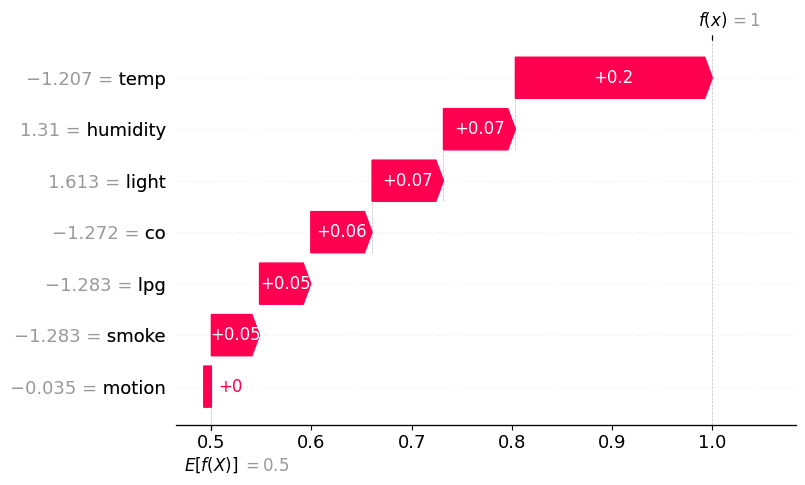

In [12]:
input_data = {
    'co': 0.003048879,
    'humidity': 75.90000153,
    'light': 0,
    'lpg': 0.005383692,
    'motion': 0,
    'smoke': 0.014022829,
    'temp': 19.60000038
}


input_data1 = {
    'co': 0.003048879,
    'humidity': 75.40000153,
    'light': 1,
    'lpg': 0.005383692,
    'motion': 0,
    'smoke': 0.014022829,
    'temp': 19.20000076
}

	


predict_and_explain(
    input_data1,
    scaler,         
    rf_model,
    explainer,
    X_train.columns
)
						


